### Imports

In [1]:
# Data manipulation and processing
import numpy as np
import pandas as pd
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import HistGradientBoostingClassifier,  HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
# Model Evaluation
from sklearn.metrics import silhouette_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import root_mean_squared_error
# Loading Bar
from tqdm import tqdm
pd.set_option('display.max_columns', None)

### Reading Data

In [2]:
train = pd.read_csv("train_earth.csv")
test = pd.read_csv("test_earth.csv")
test_gap = pd.read_csv("Gap_Test.csv")

In [3]:
soil_depth = 20
target_columns = ['N', 'P', 'K', 'Ca', 'Mg', 'S', 'Fe', 'Mn', 'Zn', 'Cu', 'B']

In [4]:
train_dropna = train.dropna().sort_values(by="PID")
X = train_dropna.drop(columns=target_columns)
Y = train_dropna[target_columns]

### Helper Functions

In [5]:
# Available (kg/ha) = ppm × soil depth (cm) × bulk density (g/cm³) × 0.1
def get_available_nutrient(X, Y_pred):
    scale = X['BulkDensity'].values.reshape(-1, 1) * soil_depth * 0.1
    Y_scaled = Y_pred * scale
    return Y_scaled

In [6]:

def score_predictions(estimator, X, Y_true):
    Y_pred = estimator.predict(X)
    Y_true_final = get_available_nutrient(X, Y_true)
    Y_pred_final = get_available_nutrient(X, Y_pred)
    return -root_mean_squared_error(Y_true_final, Y_pred_final)


estimator_last_score = {}


def eval_model(estimator, X, Y, n_splits=5, estimator_key=None, n_jobs=1, print_result=True):
    result = cross_validate(estimator, X, Y, cv=n_splits,
                            scoring=score_predictions, n_jobs=n_jobs)
    scores = -result['test_score']
    mean = np.mean(scores)
    median = np.median(scores)
    if print_result:
        print("mean score:", mean)
        print("median score:", np.median(scores))
        print("std:", np.std(scores))
        print("scores:  ", scores)
    estimator_key = estimator_key or id(estimator)
    if print_result:
        if not estimator_key in estimator_last_score:
            print("first evaluation")
        else:
            last_mean, last_median = estimator_last_score[estimator_key]
            if mean < last_mean:
                print("mean improved")
            elif mean > last_mean:
                print("mean degraded")
            else:
                print("same mean")

            if median < last_median:
                print("median improved")
            elif median > last_median:
                print("median degraded")
            else:
                print("same median")

    estimator_last_score[estimator_key] = (mean, median)
    return result

In [7]:
def eval_classifier(classifier, X, y, n_splits=5, n_jobs=1, print_result=True):
    result = cross_validate(classifier, X, y, cv=n_splits,
                            scoring='roc_auc_ovr', n_jobs=n_jobs)
    scores = result['test_score']
    if print_result:
        print("mean score:", np.mean(scores))
        print("median score:", np.median(scores))
        print("std:", np.std(scores))
        print("scores:  ", scores)
    return result

In [ ]:
# make final predictions
def predict(model, test):
    predictions = model.predict(test)
    predictions = get_available_nutrient(test, predictions)
    predictions = pd.DataFrame(
        predictions, columns=target_columns, index=test.index)
    predictions["PID"] = test["PID"]
    predictions = predictions.melt(
        id_vars=['PID'], var_name='Nutrient', value_name='Available')
    predictions = predictions.merge(right=test_gap, on=["PID", "Nutrient"])
    predictions["Gap"] = predictions["Required"] - predictions["Available"]
    predictions['ID'] = predictions['PID'] + "_" + predictions['Nutrient']
    predictions = predictions[["ID", "Gap"]]
    return predictions

In [9]:
drop_step = ("drop", FunctionTransformer(
    lambda x: x.drop(columns=["PID", "site", 'Nadir_Reflectance_Band2', 'Nadir_Reflectance_Band4', 'QA_RADSAT',
                              'SENSING_ORBIT_NUMBER', 'SR_B1', 'SR_B2', 'SR_B4', 'SR_B6', 'SolarZenith', 'ecec20',
                              'lstn', 'para', 'relativeOrbitNumber_start', 'sur_refl_b07', 'tim'])))

### Feature Engineering

#### Clustering Target
Cluster the data based on target columns. Then train a model to predict this cluster to be used in test set.

clustering:   0%|          | 0/11 [00:00<?, ?it/s]

clustering: 100%|██████████| 11/11 [00:13<00:00,  1.27s/it]


best clustering, 2


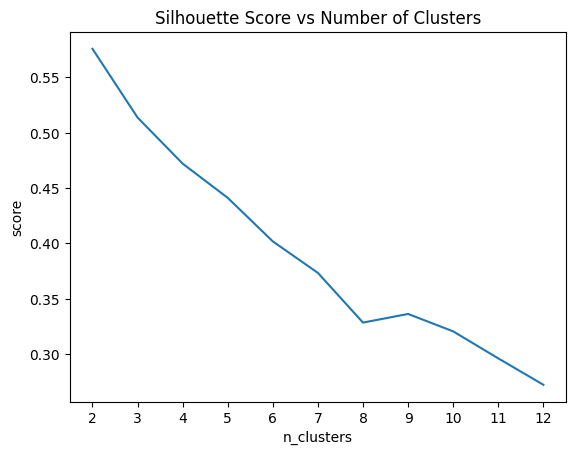

In [ ]:
# find the best number of clusters(k)
n_clusters_range = range(2, 13)

results = pd.DataFrame({"n_clusters": n_clusters_range, "score": None})

for i, n_clusters in enumerate(tqdm(n_clusters_range, desc="clustering")):

    kmeans = KMeans(n_clusters=n_clusters)

    target_cluster_k = kmeans.fit_predict(Y)

    results.iloc[i, 1] = silhouette_score(X=Y, labels=target_cluster_k)

sns.lineplot(x=results['n_clusters'], y=results['score'])

print(f"best clustering, {results.iloc[np.argmax(results['score']), 0]}")

plt.xticks(n_clusters_range)
plt.title("Silhouette Score vs Number of Clusters")

plt.show()

In [ ]:
# train the final clustering model
kmeans = KMeans(n_clusters=2, random_state=0)

target_cluster = pd.Series(data=kmeans.fit_predict(Y), index=Y.index)

silhouette_score(X=Y, labels=target_cluster)

np.float64(0.5759108016817921)

#### Max Nutrient
Find max nutrient and train a model to predict it.

In [12]:
max_nutrient = train_dropna[target_columns].apply(
    lambda x: np.argmax(x), axis=1).map(lambda x: target_columns[x])
max_nutrient_encoded = max_nutrient == 'Ca'
max_nutrient.value_counts()

Ca    6196
N     1539
Name: count, dtype: int64

Plotting: 100%|██████████| 11/11 [00:09<00:00,  1.19it/s]


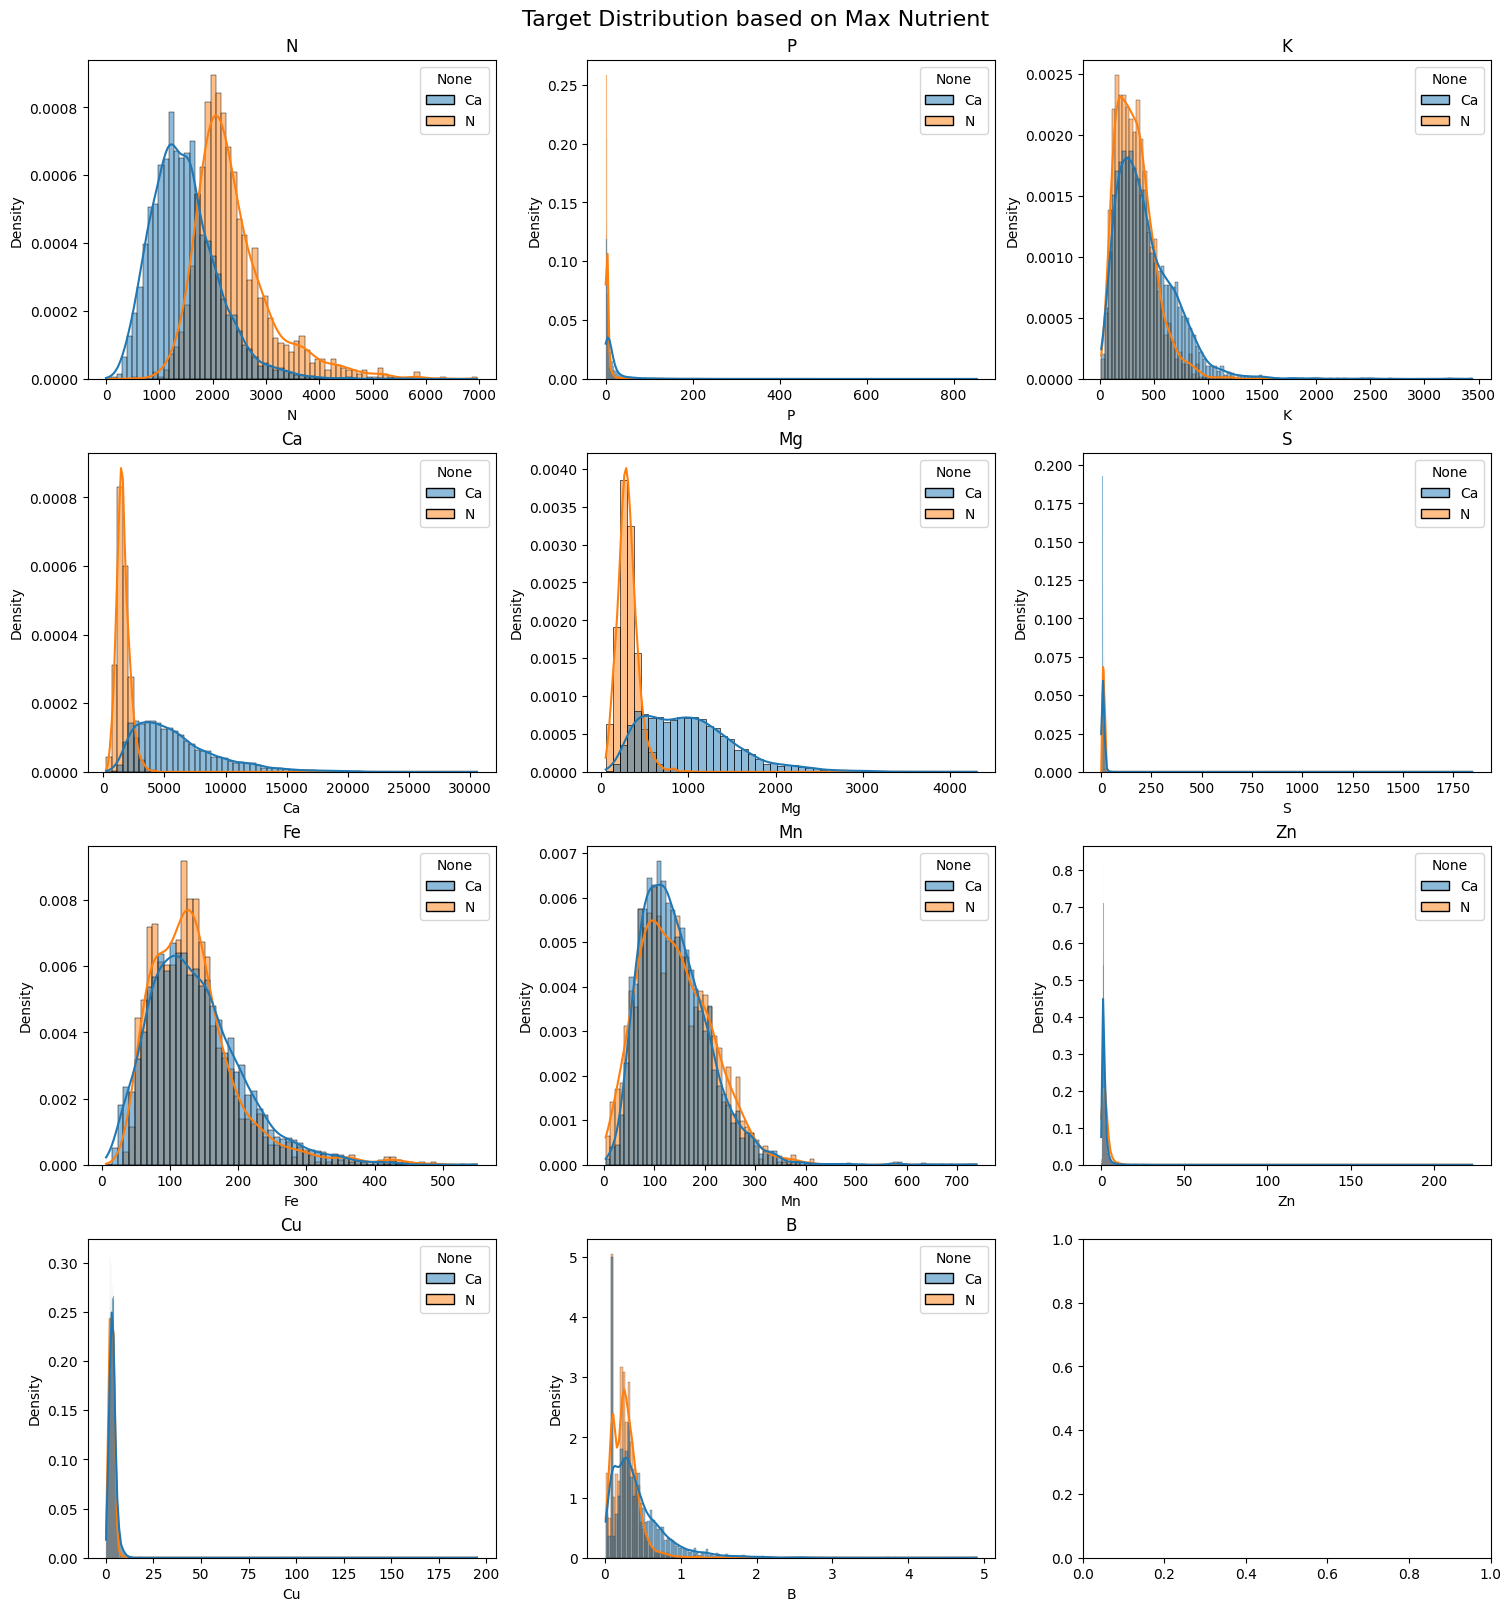

In [14]:
column_count = len(target_columns)
nrows = (column_count + 2) // 3
ncols = min(column_count, 3)
fig, axs = plt.subplots(nrows=nrows, ncols=ncols,
                        figsize=(5*ncols, 4*nrows),
                        constrained_layout=True)
axs = axs.reshape(-1)
for i, col in enumerate(tqdm(target_columns, desc="Plotting")):
    axs[i].set_title(col)
    sns.histplot(hue=max_nutrient, x=train_dropna[col], ax=axs[i],
                 stat='density',  # Normalizes each hue group separately
                 common_norm=False,  # Each hue gets its own scale
                 kde=True, )
fig.suptitle("Target Distribution based on Max Nutrient", fontsize=16)
plt.show()

The distribution of many target nutrients is different based on which nutrient is max nutrient.

#### Train Classifiers to predict max nutrient and target cluster

In [15]:

is_ca_max_hist = Pipeline(
    [("drop", FunctionTransformer(lambda x: x.drop(columns=["PID", "site", 'mb1', 'mdem', 'QA_PIXEL', 'VH']))),
     ("c", ColumnTransformer(
         [('log',  FunctionTransformer(np.log1p),
           ['B7', 'MEAN_SOLAR_ZENITH_ANGLE']),],
         remainder='passthrough', force_int_remainder_cols=False)),
     ("hist", HistGradientBoostingClassifier(random_state=0
                                             ))])


eval_classifier(is_ca_max_hist, X,
                max_nutrient_encoded, n_jobs=-1, n_splits=4)

mean score: 0.9642203879615112
median score: 0.9636138662284562
std: 0.00404297536112065
scores:   [0.95963713 0.97001668 0.9658548  0.96137293]


{'fit_time': array([2.41955113, 2.3795321 , 2.42336917, 2.44350052]),
 'score_time': array([0.03558588, 0.04193854, 0.03366446, 0.03350496]),
 'test_score': array([0.95963713, 0.97001668, 0.9658548 , 0.96137293])}

In [16]:
target_cluster_hist = Pipeline(
    [("drop", FunctionTransformer(lambda x: x.drop(columns=["PID", "site", 'mdem', 'QA_PIXEL']))),
     ("c", ColumnTransformer(
         [('log',  FunctionTransformer(np.log1p),
           ['B8A', 'CLOUDY_PIXEL_PERCENTAGE',
             'MEAN_SOLAR_ZENITH_ANGLE', 'NODATA_PIXEL_PERCENTAGE']),],
         remainder='passthrough', force_int_remainder_cols=False)),
     ("hist", HistGradientBoostingClassifier(random_state=0
                                             ))])
eval_classifier(target_cluster_hist, X,
                target_cluster, n_jobs=-1, n_splits=4)

mean score: 0.9644643452776609
median score: 0.9647462311005626
std: 0.002365150438074923
scores:   [0.96650157 0.96299089 0.96136329 0.96700163]


{'fit_time': array([2.88101244, 2.85111523, 2.86788988, 2.88239717]),
 'score_time': array([0.03401804, 0.03704524, 0.03369498, 0.03698373]),
 'test_score': array([0.96650157, 0.96299089, 0.96136329, 0.96700163])}

In [17]:
classifier_columns = X.columns
is_ca_max_hist.fit(X, max_nutrient_encoded)

target_cluster_hist.fit(X, target_cluster)

Pipeline(steps=[('drop',
                 FunctionTransformer(func=<function <lambda> at 0x000001B37E8CD1C0>)),
                ('c',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  ['B8A',
                                                   'CLOUDY_PIXEL_PERCENTAGE',
                                                   'MEAN_SOLAR_ZENITH_ANGLE',
                                                   'NODATA_PIXEL_PERCENTAGE'])])),
                ('hist', HistGradientBoostingClassifier(random_state=0))])

In [18]:
def add_is_ca_max_nutrient(X: pd.DataFrame):
    X = X.copy()
    X['is_ca_max_nutrient'] = is_ca_max_hist.predict(X[classifier_columns])
    return X

In [19]:
def add_target_cluster(X: pd.DataFrame):

    X = X.copy()

    X['target_cluster'] = target_cluster_hist.predict(X[classifier_columns])

    return X

### Train final model

In [20]:
hist = Pipeline([('target_cluster', FunctionTransformer(add_target_cluster)),
                 ('is_ca_max_nutrient', FunctionTransformer(add_is_ca_max_nutrient)),
                 drop_step,
                 ("hist", MultiOutputRegressor(HistGradientBoostingRegressor(random_state=0,
                                                                             max_iter=350,
                                                                             learning_rate=0.1,
                                                                             loss='squared_error'),
                                               n_jobs=2))])
eval_model(hist, X, Y, n_jobs=4, n_splits=4, estimator_key="hist")

mean score: 540.8949460567488
median score: 532.4234068108476
std: 15.822215311604435
scores:   [531.4451016  533.40171202 530.49338383 568.23958678]
first evaluation


{'fit_time': array([86.16001916, 86.17902827, 86.21622705, 85.99208903]),
 'score_time': array([0.81457496, 0.70640159, 0.72051501, 0.77413845]),
 'test_score': array([-531.4451016 , -533.40171202, -530.49338383, -568.23958678])}

Possible Data Leak:

During model evaluation, I used classifiers (is_ca_max_hist, target_cluster_hist) that were trained on the entire training dataset. This approach can lead to data leakage, making the cross-validation results overly optimistic and potentially unreliable. A more rigorous approach is to train these classifiers as well as the KMeans model within each cross-validation fold.

Current approach is good enough for competetion purposes.

In [21]:
hist.fit(X, Y)

Pipeline(steps=[('target_cluster',
                 FunctionTransformer(func=<function add_target_cluster at 0x000001B37E8CD3A0>)),
                ('is_ca_max_nutrient',
                 FunctionTransformer(func=<function add_is_ca_max_nutrient at 0x000001B37E8CFCE0>)),
                ('drop',
                 FunctionTransformer(func=<function <lambda> at 0x000001B358050720>)),
                ('hist',
                 MultiOutputRegressor(estimator=HistGradientBoostingRegressor(max_iter=350,
                                                                              random_state=0),
                                      n_jobs=2))])

### Make Final Predictions

In [22]:
predictions = predict(hist, test)
predictions.to_csv("submissions/hist_submission.csv", index=False)
predictions.head()

,ID,Gap
0,ID_NGS9Bx_N,-3114.918987
1,ID_YdVKXw_N,-2848.610795
2,ID_MZAlfE_N,-2949.872783
3,ID_GwCCMN_N,-3844.605911
4,ID_K8sowf_N,-3300.142351
